Created on Sun Mar 23 05:17:52 2025

@author: hongf


This program performs classification on digit images using multiple machine learning models, applies preprocessing, PCA, model tuning with K-Fold cross-validation, and exports results to PDF and text files.

This program is a well-structured ML pipeline for image classification on the SVHN dataset using several algorithms. It includes:
- Preprocessing
- PCA
- Model tuning with K-Fold CV
- Evaluation
- Logging
- PDF export

**Coding Environment**: PC Hardware is Leonovo i7 with 16GB of RAM, 500 GB HDD with Windows 11 installed running Anaconda Navigator (Spyder 5.51 running Python v3.12.2 64-bits and Jupyter Notebook. Libraries used are listed below 

These imports bring in the tools needed for: 
- Data loading and manipulation (numpy, scipy.io) 
- Machine learning models (sklearn)
- Preprocessing (scaling, PCA)
- Metrics and evaluation (accuracy, precision, etc.)
- Visualization (matplotlib)
- Outputting results (PdfPages, sys, time)

In [2]:
import numpy as np
import scipy.io as sio
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from collections import Counter
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, recall_score, precision_score
)
from sklearn.model_selection import train_test_split, GridSearchCV
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import sys
from datetime import datetime
import time


In [3]:
# There are 73257 digits for training, which are images with the shape of **(32, 32, 3)**. 
# You may need to reshape the training feature to (73257, 32, 32, 3) where 73257 is training samples. 32,32 is the size of the image and we have 3 channels of RGB.

def load_svhn_data(train_path='train_32x32.mat', test_path='test_32x32.mat'):
    
    # Loads the SVHN dataset from .mat files.
    print("Loading data...")
    train_data = sio.loadmat(train_path)
    test_data = sio.loadmat(test_path)

    train_features, train_labels = train_data['X'], train_data['y']
    test_features, test_labels = test_data['X'], test_data['y']
    
    
    # Transposes the data into a format (num_samples, height, width, channels)
    X_train = np.transpose(train_features, (3, 0, 1, 2))
    y_train = train_labels.flatten()
    X_test = np.transpose(test_features, (3, 0, 1, 2))
    y_test = test_labels.flatten()
    
    
    # Below is an example of one data sample which is the image of House Numbers. We only consider the number in the central of the image, and it is labeled as 1.
    from matplotlib import pyplot as plt
    plt.imshow(X_train[0], interpolation='nearest')
    plt.title(f'Label: {train_labels[0]}')
    my_pdf.savefig()
    plt.show()

    # Converts labels from 10 (used for digit 0 in SVHN) to 0
    y_train[y_train == 10] = 0
    y_test[y_test == 10] = 0

    labels = y_train
    class_counts = Counter(labels)
    sorted_labels = sorted(class_counts.keys())
    sorted_counts = [class_counts[label] for label in sorted_labels]

    # Plots and saves a bar chart showing class distribution of digits
    plt.figure(figsize=(10, 5))
    plt.bar(sorted_labels, sorted_counts, color='blue', alpha=0.7)
    plt.xlabel('Digit Class')
    plt.ylabel('Frequency')
    plt.title('SVHN Dataset Class Distribution by Digit')
    plt.xticks(sorted_labels)
    my_pdf.savefig()
    plt.show()

    return X_train, y_train, X_test, y_test

In [4]:
def preprocess_data(X_train, X_test):
    print("Preprocessing data...")
    
    # Flattens image data and applies standard scaling to normalize the features.
    X_train_flat = X_train.reshape(X_train.shape[0], -1)
    X_test_flat = X_test.reshape(X_test.shape[0], -1)

    # Two scatter plots are saved to PDF: before and after scaling.
    plt.figure(figsize=(10, 5))
    plt.scatter(X_train_flat[:, 0], X_train_flat[:, 1], alpha=0.3, label='Before Scaling', s=1)
    plt.title('Feature Distribution Before Scaling (First 2 Features)')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    my_pdf.savefig()
    plt.show()

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_flat)
    X_test_scaled = scaler.transform(X_test_flat)

    plt.figure(figsize=(10, 5))
    plt.scatter(X_train_scaled[:, 0], X_train_scaled[:, 1], alpha=0.3, color='green', label='After Scaling', s=1)
    plt.title('Feature Distribution After Scaling (First 2 Features)')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    my_pdf.savefig()
    plt.show()

    return X_train_scaled, X_test_scaled

In [5]:
# Reduces the dataset to a smaller sample (e.g., 100) for quicker testing.
def reduce_dataset(X_train, y_train, X_test, y_test, size=100):
    print(f"Reducing dataset to {size} samples...")
    
    # Uses stratified sampling to preserve label distribution.
    X_train_small, _, y_train_small, _ = train_test_split(
        X_train, y_train, train_size=size, stratify=y_train, random_state=42
    )
    size2 = int(size*0.2)
    X_test_small, _, y_test_small, _ = train_test_split(
        X_test, y_test, train_size=size2, stratify=y_test, random_state=42
    )
    return X_train_small, y_train_small, X_test_small, y_test_small

In [6]:
# Reduces dimensionality of data using PCA
def apply_pca(X_train, X_test, n_components=60):
    print(f"Applying PCA with {n_components} components...")
    
    # Transforms both training and test sets.
    pca = PCA(n_components=n_components)
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)

    # Saves a plot showing how much variance is captured by each PCA component.
    plt.figure(figsize=(10, 5))
    plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
    plt.xlabel('Number of Components')
    plt.ylabel('Cumulative Explained Variance')
    plt.title('Explained Variance by PCA Components')
    plt.grid(True)
    my_pdf.savefig()
    plt.show()

    return X_train_pca, X_test_pca, pca

In [7]:
""" 
Fits a model and evaluates it using:
- Accuracy
- Precision
- Recall
- F1 Score
"""

def train_and_evaluate_model(model, X_train, y_train, X_test, y_test, title="Confusion Matrix"):
    print(f"Training {model.__class__.__name__}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    # Confusion matrix (visualized and saved to PDF)
    cm = confusion_matrix(y_test, y_pred)
    print(f"{model.__class__.__name__} Accuracy : {accuracy:.4f}")
    print(f"{model.__class__.__name__} Precision: {precision:.4f}")
    print(f"{model.__class__.__name__} Recall   : {recall:.4f}")
    print(f"{model.__class__.__name__} F1-Score : {f1:.4f}")

    ConfusionMatrixDisplay(cm).plot()
    plt.title(f"{title} - {model.__class__.__name__}")
    my_pdf.savefig()
    plt.show()

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'model': model
    }

In [8]:
# Each function uses GridSearchCV to find the best hyperparameters:
def tune_knn(X_train, y_train, cv=3):
    param_grid = {
        'n_neighbors': [17, 23, 31],
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan']
    }
    grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=cv, verbose=0, n_jobs=-1)
    grid.fit(X_train, y_train)
    return grid.best_estimator_, grid.best_params_, grid.best_score_

def tune_random_forest(X_train, y_train, cv=3):
    param_grid = {
        'n_estimators': [500, 800],
        'max_depth': [50, 80, None],
        'max_features': ['sqrt', 'log2'],
        'criterion': ['gini', 'entropy']
    }
    grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=cv, verbose=0, n_jobs=-1)
    grid.fit(X_train, y_train)
    return grid.best_estimator_, grid.best_params_, grid.best_score_

def tune_bagging(X_train, y_train, cv=3):
    base = DecisionTreeClassifier()
    param_grid = {
        'n_estimators': [200, 300],
        'max_samples': [0.8, 1.0],
        'max_features': [0.5, 0.8, 1.0],
        'estimator__max_depth': [None, 20, 30]
    }
    bagging = BaggingClassifier(estimator=base, random_state=42)
    grid = GridSearchCV(bagging, param_grid, cv=cv, verbose=0, n_jobs=-1)
    grid.fit(X_train, y_train)
    return grid.best_estimator_, grid.best_params_, grid.best_score_

def tune_svm(X_train, y_train, cv=3):
    param_grid = {
        'C': [0.1, 1, 10],
        'gamma': ['scale', 0.01, 0.001],
        'kernel': ['rbf', 'linear']
    }
    grid = GridSearchCV(SVC(), param_grid, cv=cv, verbose=0, n_jobs=-1)
    grid.fit(X_train, y_train)
    return grid.best_estimator_, grid.best_params_, grid.best_score_


In [9]:
"""
This is the core logic that:
- Loads and preprocesses data
- Loops over different training set sizes (e.g., [100])
- Applies PCA
For each model:
    - Tries different cv values: [3, 5, 10]
    - Trains, evaluates, and records metrics
    - Plots:
        - Accuracy vs. Sample Size
        - Bar chart comparing model performance
    - Saves:
        - Evaluation results to results_0.txt
        - Charts to my_charts_output.pdf
"""
def main():
    X_train, y_train, X_test, y_test = load_svhn_data()
    X_train, X_test = preprocess_data(X_train, X_test)

    sample_sizes = [500]
    model_names = ['kNN', 'Random Forest', 'Bagging', 'SVM']
    tune_functions = [tune_knn, tune_random_forest, tune_bagging, tune_svm]

    accuracy_matrix = {name: [] for name in model_names}
    time_matrix = {name: [] for name in model_names}
    metrics_matrix = {name: [] for name in model_names}
    best_params_matrix = {name: [] for name in model_names}

    
    for size in sample_sizes:
        print(f"\n--- Training with sample size: {size} ---")
        X_train_small, y_train_small, X_test_small, y_test_small = reduce_dataset(X_train, y_train, X_test, y_test, size=size)
        X_train_pca, X_test_pca, _ = apply_pca(X_train_small, X_test_small, n_components=60)

        for model_name, tune_func in zip(model_names, tune_functions):
            best_cv = None
            best_cv_score = 0
            best_model = None
            best_params = None

            for cv_val in [3, 5, 10]:
                try:
                    model, params, score = tune_func(X_train_pca, y_train_small, cv=cv_val)
                    if score > best_cv_score:
                        best_cv_score = score
                        best_cv = cv_val
                        best_model = model
                        best_params = params
                except Exception as e:
                    print(f"CV={cv_val} failed for {model_name}: {e}")
                    continue

            print(f"Best CV for {model_name}: {best_cv} (CV Score: {best_cv_score:.4f})")

            start_time = time.time()
            result = train_and_evaluate_model(best_model, X_train_pca, y_train_small, X_test_pca, y_test_small, title=f"Size {size}")
            end_time = time.time()
            time_taken = round(end_time - start_time, 2)

            accuracy_matrix[model_name].append(round(result['accuracy'] * 100, 2))
            time_matrix[model_name].append(time_taken)
            metrics_matrix[model_name].append(result)
            best_params_matrix[model_name].append({'best_cv': best_cv, 'cv_score': best_cv_score, 'params': best_params})

    # Plot accuracy vs sample size
    plt.figure(figsize=(10, 6))
    for model_name in model_names:
        plt.plot(sample_sizes, accuracy_matrix[model_name], label=model_name, marker='o')
    plt.title("Model Accuracy vs Sample Size")
    plt.xlabel("Training Sample Size")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    my_pdf.savefig()
    plt.show()

    # Save results
    with open("results_0.txt", "w") as f:
        f.write("Model Accuracy vs Sample Size\n")
        f.write("--------------------------------\n")
        for i, size in enumerate(sample_sizes):
            f.write(f"\nSample Size: {size}\n\n")
            for model_name in model_names:
                result = metrics_matrix[model_name][i]
                time_str = time_matrix[model_name][i]
                best_params_str = best_params_matrix[model_name][i]
                f.write(f"\n{model_name:15}: {time_str} seconds")
                f.write(f"\nBest parameters: {best_params_str}\n")
                f.write(f"   -> Accuracy: {round(result['accuracy'] * 100, 2)}%\n")
                f.write(f"   -> Precision: {round(result['precision'] * 100, 2)}%\n")
                f.write(f"   -> Recall   : {round(result['recall'] * 100, 2)}%\n")
                f.write(f"   -> F1-Score : {round(result['f1'] * 100, 2)}%\n")

        f.write("\nSummary Table:\n")
        f.write(f"{'Model':15} {' | '.join([str(s) for s in sample_sizes])} \n")
        for metric in ['accuracy', 'precision', 'recall', 'f1']:
            f.write("\n")
            for model_name in model_names:
                values = " | ".join([f"{metrics_matrix[model_name][i][metric]*100:.2f}%" for i in range(len(sample_sizes))])
                f.write(f"{model_name:15}  -> {metric.title():10} : {values}\n")

    # Bar chart of performance metrics
    metrics = ['accuracy', 'precision', 'recall', 'f1']
    bar_width = 0.2
    x = np.arange(len(model_names))
    business_colors = ['#003f5c', '#58508d', '#bc5090', '#ffa600']

    plt.figure(figsize=(10, 6))
    for i, metric in enumerate(metrics):
        values = [metrics_matrix[model][0][metric] * 100 for model in model_names]
        plt.bar(x + i * bar_width, values, width=bar_width, label=metric.title(), color=business_colors[i])

    plt.xticks(x + bar_width * 1.5, model_names)
    plt.title("Model Performance Comparison")
    plt.ylabel("Score (%)")
    plt.ylim(0, 100)
    plt.legend()
    plt.grid(axis='y')
    plt.tight_layout()
    my_pdf.savefig()
    plt.show()
    

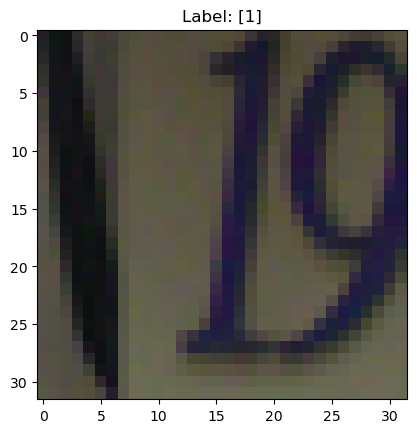

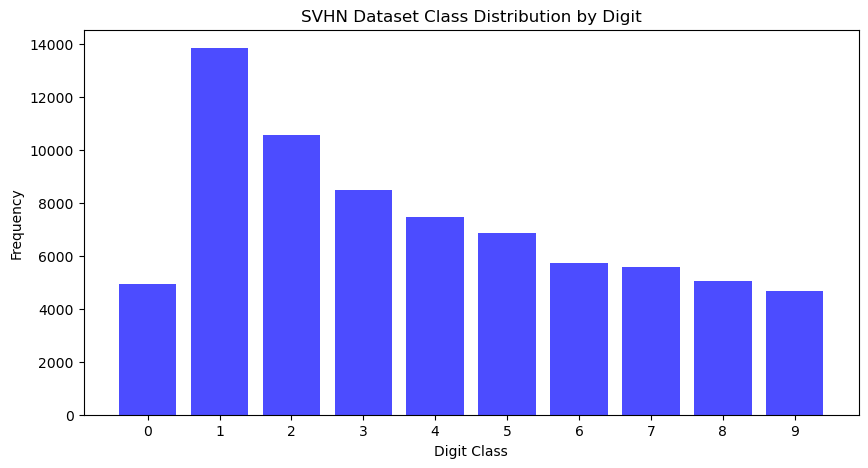

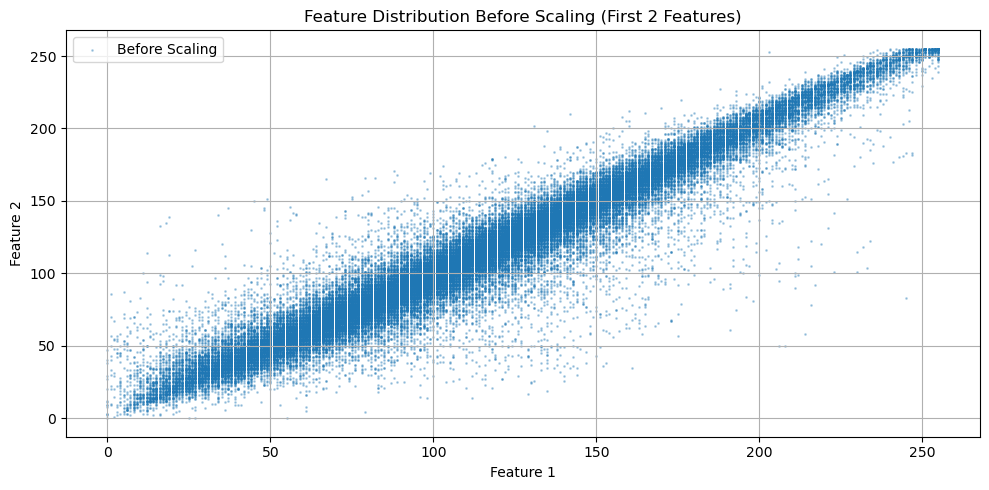

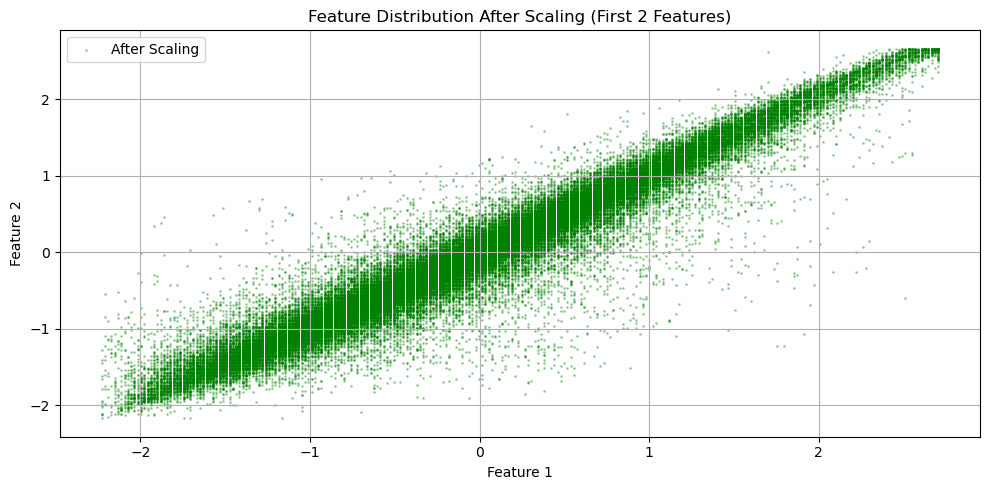

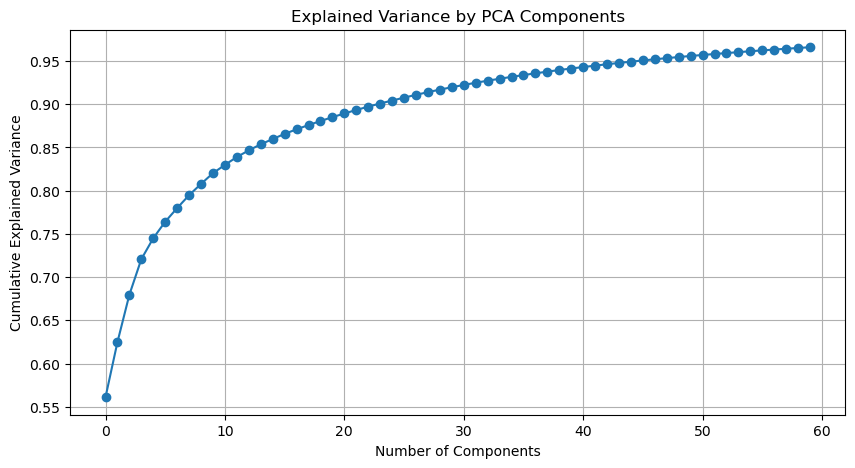

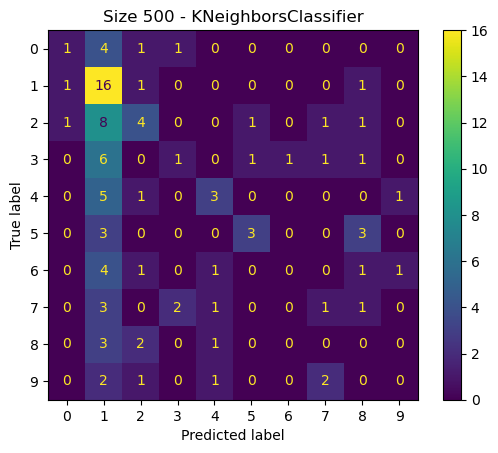

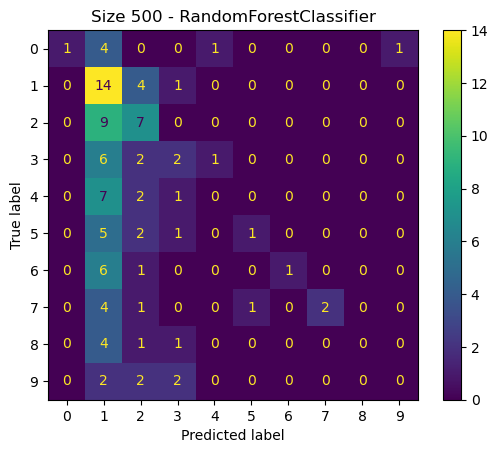

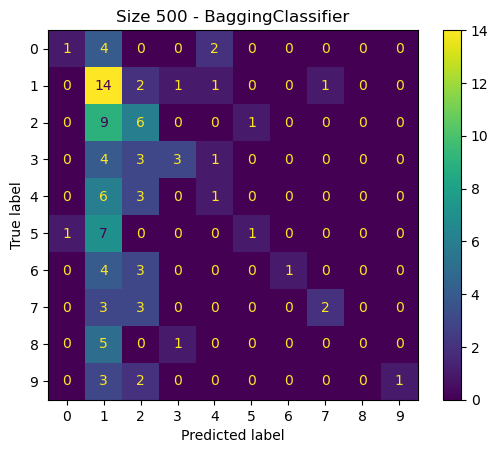

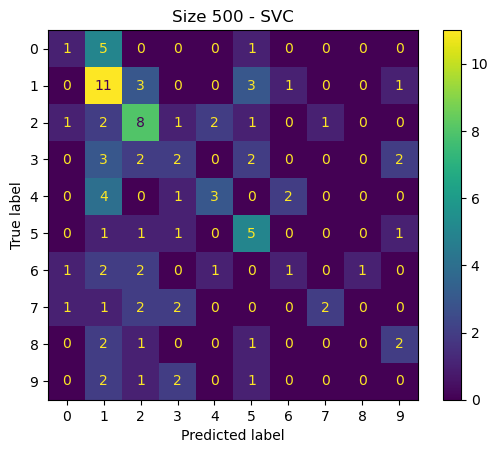

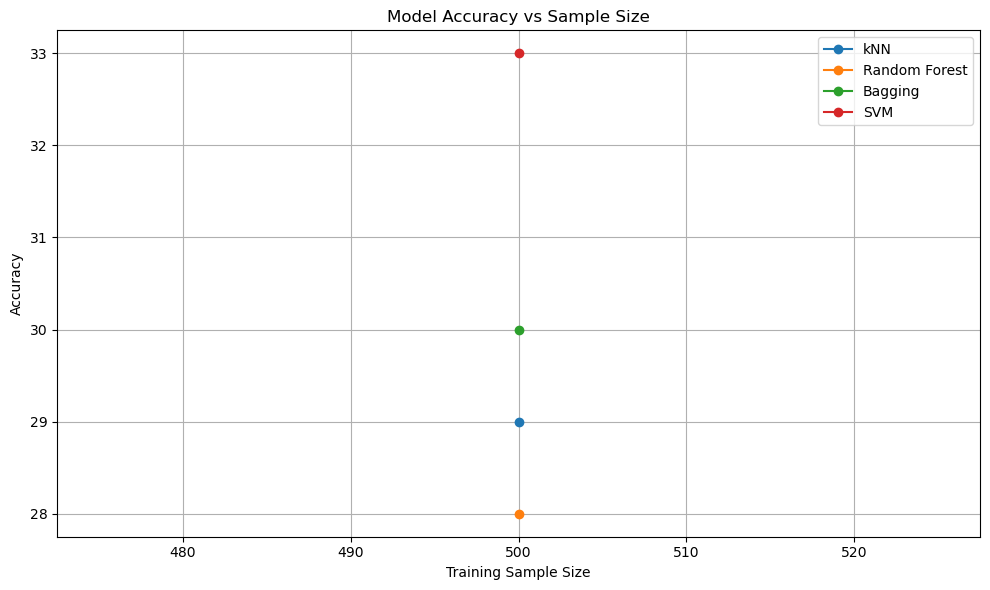

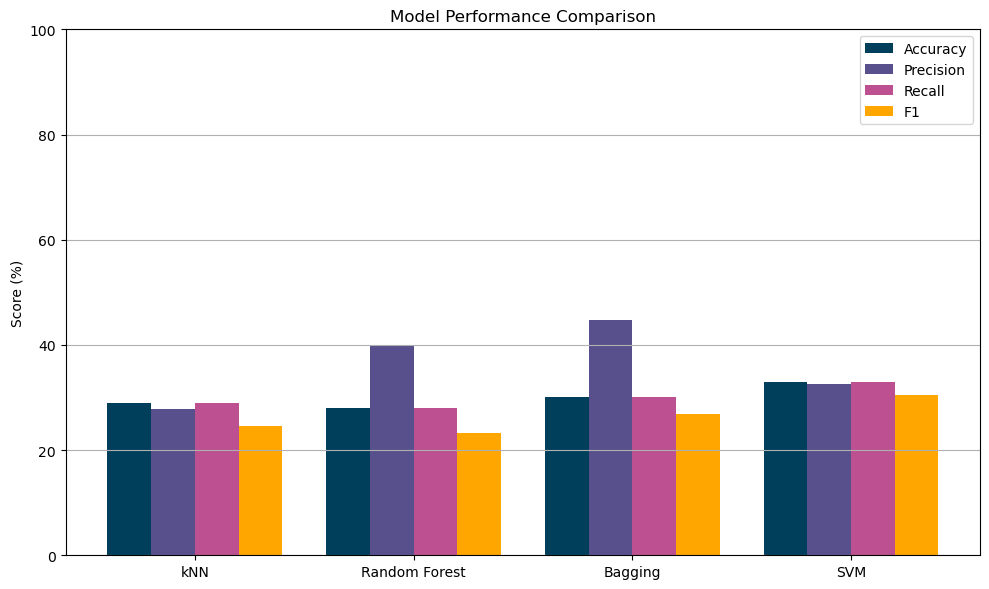

In [10]:
if __name__ == "__main__":
    
    # Before running main():
    # Redirect print output to file
    my_log_file = open("My_output_log.txt", "w")
    sys.stdout = my_log_file
    
    # PDF to collect all figures
    my_pdf = PdfPages("my_charts_output.pdf")
    
    # run the main program 
    main()
    
    # close pdf file 
    my_pdf.close()
    
    # Restore default stdout and close files
    sys.stdout = sys.__stdout__
    my_log_file.close()
    
    # All print() output goes to My_output_log.txt, and all plt.savefig() calls store charts in my_charts_output.pdf.